## __Reflection__
A single decision tree can be grown until it perfectly classifies every training example. What goes wrong when you do that, and how does a random forest address that problem?
Each tree in a random forest is trained on a different random sample of the data. Why does that randomness help the ensemble generalise better than any individual tree?
When a random forest makes a prediction, it aggregates the outputs of many trees. What does that aggregation step look like for a regression problem compared to a classification problem?

__Question 1.__

 **A single decision tree can be grown until it perfectly classifies every training example. What goes wrong when you do that, and how does a random forest address that problem?**
 
> The tree **overfits** the training data, learning noise and small patterns that do not generalise to unseen data. A random forest reduces this overfitting by combining many different trees, producing a more stable and generalisable model.

__Question 2.__

**Each tree in a random forest is trained on a different random sample of the data. Why does that randomness help the ensemble generalise better than any individual tree?**

> Random sampling makes the trees **different and less correlated**. Each tree makes different errors, so when their predictions are combined, individual errors tend to cancel out, improving generalisation.

__Question 3.__
 
**When a random forest makes a prediction, it aggregates the outputs of many trees. What does that aggregation step look like for a regression problem compared to a classification problem?**

> * **Regression:** The forest **averages the predictions** from all trees.
> * **Classification:** The forest uses **majority voting**—the class predicted by the most trees becomes the final prediction.


## **Learning objectives**

* Understand how random forests differ from decision trees.
* Understand the training process of random forests and how we can use them to make predictions.
* Know how to build a random forest regression model.
* Understand how to use random forests to assess predictive variable importance.

## 1. **Introduction to random forests**

### **Overfitting in decision trees**

Overfitting is a risk when working with decision trees – it is easy for the tree to become too complex, and thus fit details of the individual data points rather than the overall properties of the distributions they are drawn from.

This issue can be addressed by using **random forests**.

### **What is ensemble learning?**

Ensemble learning in machine learning is the practice of **combining multiple models** to try and achieve higher overall model performance.

In general, ensembles consist of multiple **heterogeneous or homogeneous** models trained on the same dataset.

Each of these models is used to make predictions using input (either exactly the same or samples out of the same data), then  **aggregated** across all models in some way (e.g. by taking the mean or having a weighted mean) to produce the final output.

The  **`random forest`** is an example of a commonly used ensemble model.

### **What is a random forest?**

A random forest is a powerful non-parametric algorithm and an **ensemble** method **built on decision trees**, meaning that it relies on aggregating the results of an ensemble of decision trees.

The ensembled trees are **randomised** and the output is the **aggregated prediction** of the individual trees.

*The mean prediction is used for a regression problem while classification problems use the mode of the ensembled trees as opposed to the mean.*

## 2. **How do random forests work?**

### **Fitting the data:**

Keep in mind that `N` refers to the **number of observations** (rows) in the training dataset, and `p` is the **number of predictor variables** (columns). The following is the typical algorithm for a random forest:

1. **Bootstrapping**: Drawing *with replacement* from the training dataset, randomly sampled `N` observations.
<br>

2. Use the `N` observations to **grow a random forest tree** as follows:<br>
_<br>
At each node:<br>
i. Select a random subset, `m`, of predictor variables, where $m<\sqrt{p}$.<br>
ii. Pick the best variable/split-point among the selected predictor variables.<br>
iii. Divide the data into two subsets based on the selected split.<br>
iv. Repeat until the stopping criteria are satisfied (e.g. minimum node sample size reached)._
<br>

3. Repeat until the **desired number of random forest trees** is reached.

Since we draw randomly with replacement from the training data during the bootstrapping step, it is possible that:
- Some data **samples get resampled** and thus reused when fitting different trees in the random forest.
- Some data **samples don't get sampled at all** and thus do not get used in fitting the random forest.

This means that the **dataset each tree is grown on** is **slightly different**, so random forests are **less likely to overfit** than decision trees.

### **Making predictions:**

Random forests **combine multiple trees to make a prediction** as follows:

<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/random_forest.png">

The somewhat surprising result with such ensemble methods is that the sum can be greater than the parts: that is, a majority vote among a number of estimators can end up being better than any of the individual estimators doing the voting! (An estimator is a tree.)

## 3. **Building a random forest regression model**

Now that we have an understanding of how random forests work, let's **implement** one **using `scikit-learn`**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
from plot import style_plot

In [3]:
df = pd.read_csv("../data/house_price.csv")
display(df.head())

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


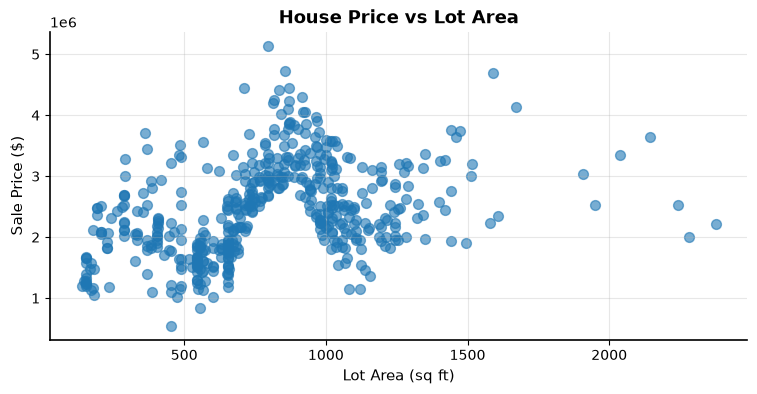

In [4]:
# Plotting the data

X = df["LotArea"]       # independent variable
y = df["SalePrice"]     # dependent variable

fig, ax = plt.subplots(figsize=(9, 4))

ax.scatter(X, y, alpha=0.6, s=50)

# Apply custom styling
style_plot(
    ax,
    title="House Price vs Lot Area",
    xlabel="Lot Area (sq ft)",
    ylabel="Sale Price ($)"
)

plt.show()

In [5]:
# standardise features
scaler = StandardScaler()

# Convert to numpy array first to apply np.newaxis
X_scaled = scaler.fit_transform(np.array(X)[:,np.newaxis])

# Train test split
X_train, X_test, y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=6
)

### **Training**

This process of fitting a decision tree to our data can be done in `scikit-learn` with the ``RandomForestRegressor`` estimator:

As with decision trees, random forests also have hyperparameters. Some of the more important ones include:

- **n_estimators**: The number of trees to include in the forest.
- **min_samples_leaf**: The minimum number of samples required to be at a leaf node.
- **max_depth**: The maximum depth of each forest tree (i.e. the number of nodes between root and leaf node).
- **random_state**: A number used to seed the random number generator. Ensures that we get the same tree each time we call model.fit() – _this particular hyperparameter is important in random forests since their training procedure is inherently random._
- **criterion**: The function to measure the quality of a split. The model uses the mean squared error (MSE) by default.

> To learn more about other RandomForestRegressor hyperparameters, run `help(RandomForestRegressor)` in a new cell.

In [6]:

# Create a random forest with 100 trees and a maximum depth of 5
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=6
)

# Train the model
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",6
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of th

### **Why add `random_state=6`?**

Random forests use randomness when creating the individual trees. Setting `random_state` ensures that you get **reproducible results** each time you run the notebook.

Your model therefore has:

* **100 trees** → `n_estimators=100`
* **Maximum tree depth of 5** → `max_depth=5`
* **Reproducible results** → `random_state=6`


### **Testing**

To evaluate the performance of our model, we can report the **mean squared error** or **plot** predicted output vs. expected output.

In [7]:
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 593324.1537


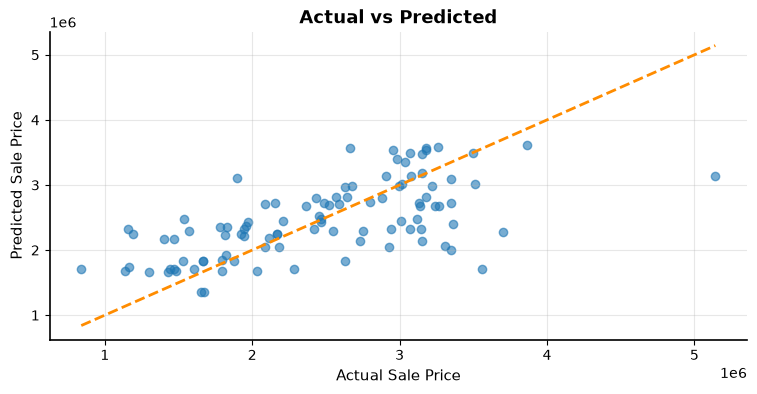

In [8]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(9, 4))

# Plot actual vs predicted values
ax.scatter(y_test, y_pred, alpha=0.6)

# Add perfect prediction reference line
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color = "darkorange",
    linewidth = 2
)

# Apply custom styling
style_plot(
    ax,
    title="Actual vs Predicted",
    xlabel="Actual Sale Price",
    ylabel="Predicted Sale Price",
    spine_width=1.2
)

plt.show()

### **Tuning model hyperparameters**

In most cases, the default hyperparameter values do not offer the best model performance. In such cases, we have to **tune model hyperparameters** to **yield the best-performing model**.

Let's make some changes to the `n_estimators` parameter and compare the results: